In [60]:
%matplotlib inline

import time
from collections.abc import Callable

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from d2l import torch as d2l

In [61]:
# Airfoil Dataset Loader

d2l.DATA_HUB["airfoil"] = (
    d2l.DATA_URL
    + "airfoil_self_noise.dat",
    "76e5be1548fd8222e5074cf0faae75edff8cf93f",
)

def get_airfoil_data(
    batch_size: int = 10,
    num_examples: int = 1500,
) -> tuple[
    DataLoader,
    int,
]:
    file_path = d2l.download(
        "airfoil",
        folder="../data",
    )

    raw_data = np.genfromtxt(
        file_path,
        dtype=np.float32,
        delimiter="\t",
    )

    standardized_data = (
        raw_data
        - raw_data.mean(
            axis=0,
        )
    ) / raw_data.std(
        axis=0,
    )

    data = torch.from_numpy(
        standardized_data
    )

    features = data[
        :num_examples,
        :-1,
    ]

    targets = data[
        :num_examples,
        -1,
    ]

    data_loader: DataLoader = (
        d2l.load_array(
            (
                features,
                targets,
            ),
            batch_size,
            is_train=True,
        )
    )

    return (
        data_loader,
        features.shape[1],
    )

In [62]:
# Linear Regression & Loss

ModelFunction = Callable[
    [torch.Tensor],
    torch.Tensor,
]

def linear_regression(
    X: torch.Tensor,
    weights: torch.Tensor,
    bias: torch.Tensor,
) -> torch.Tensor:
    return (
        X @ weights
        + bias
    )
    
def squared_loss(
    predictions: torch.Tensor,
    targets: torch.Tensor,
) -> torch.Tensor:
    targets = targets.reshape(
        predictions.shape
    )
    
    return (
        predictions - targets
    ).pow(2) / 2
    
@torch.no_grad()
def evaluate_loss(
    model: ModelFunction,
    data_loader: DataLoader,
) -> float:
    
    total_loss = 0.0
    total_examples = 0
    
    for X, targets in data_loader:
        losses = squared_loss(
            model(X),
            targets,
        )
        
        total_loss += losses.sum().item()
        total_examples += losses.numel()
     
        
    return (
        total_loss
        / total_examples
    )

In [63]:
# SGD from Scratch

OptimizerFunction = Callable[
    [
        list[torch.Tensor],
        list[torch.Tensor] | None,
        dict[str, float],
    ],
    None,
]

def scratch_sgd(
    parameters: list[torch.Tensor],
    states: list[torch.Tensor] | None,
    hyperparameters: dict[str, float],
) -> None:
    del states

    learning_rate = hyperparameters[
        "learning_rate"
    ]
    
    with torch.no_grad():
        for parameter in parameters:
            gradient = parameter.grad

            if gradient is None:
                continue
            
            # batch_loss.mean()에서 이미 평균을 계산했으므로
            # Batch Size로 다시 나누지 않음
            parameter.add_(
                gradient,
                alpha=-learning_rate,
            )
            
            gradient.zero_()

In [64]:
# Generic Training Function

TrainingResult = tuple[
    list[float],
    list[float],
]


def train_scratch(
    trainer_fn: OptimizerFunction,
    states: list[torch.Tensor] | None,
    hyperparameters: dict[str, float],
    data_loader: DataLoader,
    num_features: int,
    num_epochs: int = 2,
) -> TrainingResult:
    weights = torch.normal(
        mean=0.0,
        std=0.01,
        size=(
            num_features,
            1,
        ),
        requires_grad=True,
    )

    bias = torch.zeros(
        1,
        requires_grad=True,
    )

    def model(
        X: torch.Tensor,
    ) -> torch.Tensor:
        return linear_regression(
            X,
            weights,
            bias,
        )

    elapsed_training_time = 0.0
    evaluation_times: list[float] = []
    evaluation_losses: list[float] = []

    examples_since_evaluation = 0

    for _ in range(num_epochs):
        for X, targets in data_loader:
            start_time = time.perf_counter()

            predictions = model(X)

            # 각 Minibatch example의 Loss를 평균
            batch_loss = squared_loss(
                predictions,
                targets,
            ).mean()

            # Gradient 계산
            batch_loss.backward()

            trainer_fn(
                [
                    weights,
                    bias,
                ],
                states,
                hyperparameters,
            )

            elapsed_training_time += (
                time.perf_counter()
                - start_time
            )

            examples_since_evaluation += (
                X.shape[0]
            )

            if examples_since_evaluation >= 200:
                evaluation_times.append(
                    elapsed_training_time
                )

                evaluation_losses.append(
                    evaluate_loss(
                        model,
                        data_loader,
                    )
                )

                examples_since_evaluation = 0

    print(
        f"loss: "
        f"{evaluation_losses[-1]:.3f}, "
        f"{elapsed_training_time / num_epochs:.3f} "
        f"sec/epoch"
    )

    return (
        evaluation_times,
        evaluation_losses,
    )

In [65]:
# Batch Size Experiment Wrapper

def train_with_batch_size(
    learning_rate: float,
    batch_size: int,
    num_epochs: int = 2,
) -> TrainingResult:

    data_loader, num_features = (
        get_airfoil_data(
            batch_size=batch_size,
        )
    )

    return train_scratch(
        trainer_fn=scratch_sgd,
        states=None,
        hyperparameters={
            "learning_rate": learning_rate,
        },
        data_loader=data_loader,
        num_features=num_features,
        num_epochs=num_epochs,
    )

In [66]:
# 1. Full Gradient Descent

full_gradient_result = (
    train_with_batch_size(
        learning_rate=1.0,
        batch_size=1500,
        num_epochs=10,
    )
)

loss: 0.248, 0.001 sec/epoch


In [67]:
# 2. Stochastic Gradient Descent

stochastic_result = (
    train_with_batch_size(
        learning_rate=0.005,
        batch_size=1,
        num_epochs=2,
    )
)

loss: 0.245, 0.302 sec/epoch


In [68]:
# 3. Minibatch SGD: Batch Size 100

minibatch_100_result = (
    train_with_batch_size(
        learning_rate=0.4,
        batch_size=100,
        num_epochs=2,
    )
)

loss: 0.258, 0.004 sec/epoch


In [69]:
# 4. Minibatch SGD: Batch Size 10

minibatch_10_result = (
    train_with_batch_size(
        learning_rate=0.05,
        batch_size=10,
        num_epochs=2,
    )
)

loss: 0.244, 0.032 sec/epoch


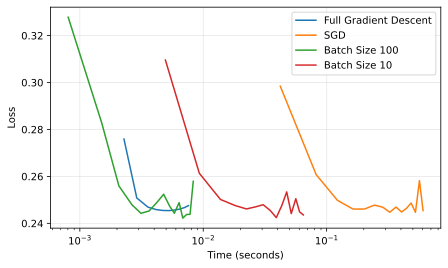

In [70]:
#  Time과 Loss 비교

experiment_results = [
    full_gradient_result,
    stochastic_result,
    minibatch_100_result,
    minibatch_10_result,
]

experiment_names = [
    "Full Gradient Descent",
    "SGD",
    "Batch Size 100",
    "Batch Size 10",
]

d2l.set_figsize(
    (7, 4)
)

for (
    experiment_name,
    (
        evaluation_times,
        evaluation_losses,
    ),
) in zip(
    experiment_names,
    experiment_results,
):
    d2l.plt.plot(
        evaluation_times,
        evaluation_losses,
        label=experiment_name,
    )

d2l.plt.xscale("log")
d2l.plt.xlabel("Time (seconds)")
d2l.plt.ylabel("Loss")
d2l.plt.legend()
d2l.plt.grid(
    alpha=0.3
)